In [1]:
import pandas as pd
import numpy as np
import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
import os

def train_state_model(df, state_name, save_verification_plot=True, 
                      verification_dir='plots', random_seed=42):
    """
    Fits the Bayesian Gamma Quadratic model, extracts stats, 
    and saves a verification plot.
    """
    # 1. Prepare Data (Add Offset)
    offset = 0.1
    df = df.copy()
    df['radiance_shifted'] = df['viirs_radiance'] + offset
    
    # 2. Define Model
    # Quadratic Identity Link: Fits a parabola, but additive (not exponential)
    model = bmb.Model(
        "radiance_shifted ~ mean_impervious + I(mean_impervious**2)", 
        data=df, 
        family="gamma", 
        link="identity"
    )
    
    # 3. Fit Model
    # Using standard PyMC sampler for stability with Identity link
    print(f"[{state_name}] Fitting model...")

    safe_init = {
        "Intercept": 10.0,
        "mean_impervious": 0.01,
        "I(mean_impervious ** 2)": 0.0,
        "alpha_log__": 0.7
    }

    results = model.fit(draws=2000, tune=1000, chains=2, random_seed=random_seed, mode='NUMBA', cores=4, initvals=safe_init)

    # 4. Extract Summary Statistics
    summary = az.summary(results)
    print(summary.index.values)
    stats = {
        'state_name': state_name,
        'intercept': summary.loc['Intercept', 'mean'],
        'beta_linear': summary.loc['mean_impervious', 'mean'],
        'beta_quad': summary.loc['I(mean_impervious ** 2)', 'mean'],
        'alpha': summary.loc['alpha', 'mean']
    }
    
    # ---------------------------------------------------------
    # 5. VERIFICATION PLOTTING
    # ---------------------------------------------------------
    if save_verification_plot:
        if not os.path.exists(verification_dir):
            os.makedirs(verification_dir)
            
        # A. Smooth Grid Prediction
        grid_data = pd.DataFrame({"mean_impervious": np.linspace(0, 100, 200)})
        pps_grid = model.predict(results, data=grid_data, kind="pps", inplace=False)
        grid_samples = pps_grid.posterior_predictive["radiance_shifted"].stack(sample=("chain", "draw")).values

        # Calculate Stats
        y_median = np.median(grid_samples, axis=1) - offset
        y_lower = np.percentile(grid_samples, 5, axis=1) - offset
        y_upper = np.percentile(grid_samples, 95, axis=1) - offset

        # B. Future Dots (Simulated Scenarios)
        target_imps = [20, 30, 50, 80]
        future_targets = pd.DataFrame({"mean_impervious": target_imps})
        pps_future = model.predict(results, data=future_targets, kind="pps", inplace=False)
        future_samples = pps_future.posterior_predictive["radiance_shifted"].stack(sample=("chain", "draw")).values

        future_x = []
        future_y = []
        for i, imp in enumerate(target_imps):
            # Grab 30 random draws
            draws = np.random.choice(future_samples[i, :], size=30) - offset
            future_y.extend(draws)
            # Jitter X
            future_x.extend([imp] * 30 + np.random.normal(0, 1.5, size=30))

        # C. Plot Construction
        plt.figure(figsize=(10, 6))

        # Observed Data
        sns.scatterplot(data=df, x='mean_impervious', y='viirs_radiance', 
                        color='black', alpha=0.15, s=10, linewidth=0, label='Observed Data')

        # Model Trend
        plt.plot(grid_data['mean_impervious'], y_median, color='#005b96', linewidth=3, label='Quadratic Trend (Identity Link)')
        plt.fill_between(grid_data['mean_impervious'], y_lower, y_upper, color='#005b96', alpha=0.2, label='90% Prediction Interval')

        # Forecasts
        plt.scatter(future_x, future_y, color='#d62728', edgecolor='white', 
                    s=60, alpha=0.9, zorder=5, label='Simulated Forecasts')

        plt.xlabel('Imperviousness (%)', fontsize=12)
        plt.ylabel('VIIRS Night Light Radiance', fontsize=12)
        plt.title(f'State: {state_name} - Bayesian Gamma Regression', fontsize=14)
        plt.legend(loc='upper left')
        plt.grid(True, alpha=0.2)
        plt.xlim(-2, 102)

        # User specified limits
        plt.ylim(bottom=-50, top=200)

        plt.tight_layout()
        
        # Save and Close
        save_path = os.path.join(verification_dir, f"{state_name}_verification.png")
        plt.savefig(save_path, dpi=150)
        plt.close() # Important to free memory in a loop
        print(f"[{state_name}] Plot saved to {save_path}")
    
    return stats

In [2]:
import numpy as np
from scipy.stats import gamma

def simulate_future_brightness_vectorized(
    imp_array, 
    state_id_array, 
    param_lookup_dict,
    current_rad_array, 
    mask_array,
    upper_quantile=0.90,
    block_info=None # <--- NEW ARGUMENT (Dask populates this automatically)
):
    """
    Vectorized simulation with Dask-aware Random Seeding.
    """
    
    # -------------------------------------------------------------------------
    # 0. SETUP UNIQUE RNG SEED (THE FIX)
    # -------------------------------------------------------------------------
    if block_info is not None:
        # Use the chunk's unique location (e.g., [0, 2]) to create a deterministic seed
        # We hash the location to get a unique integer for this specific block
        chunk_loc = block_info[0]['chunk-location']
        unique_seed = abs(hash(str(chunk_loc))) % (2**32)
        rng = np.random.default_rng(unique_seed)
    else:
        # Fallback for non-dask testing
        rng = np.random.default_rng()

    # -------------------------------------------------------------------------
    # 1. & 2. Parameter Lookup (Unchanged)
    # -------------------------------------------------------------------------
    all_keys = list(param_lookup_dict.keys())
    if not all_keys:
        return np.zeros_like(imp_array)
    max_id = int(np.max(all_keys))
    
    # Init lookup tables
    intercepts = np.zeros(max_id + 1)
    linears = np.zeros(max_id + 1)
    quads = np.zeros(max_id + 1)
    alphas = np.zeros(max_id + 1)
    
    for sid, params in param_lookup_dict.items():
        sid = int(sid)
        intercepts[sid] = params['intercept']
        linears[sid] = params['beta_linear']
        quads[sid] = params['beta_quad']
        alphas[sid] = params['alpha']
        
    safe_ids = np.nan_to_num(state_id_array, nan=0).astype(int)
    safe_ids = np.clip(safe_ids, 0, max_id)
    
    c_int = intercepts[safe_ids]
    c_lin = linears[safe_ids]
    c_quad = quads[safe_ids]
    c_alpha = alphas[safe_ids]
    
    # -------------------------------------------------------------------------
    # 3. Calculate Distribution Properties
    # -------------------------------------------------------------------------
    mu = c_int + (c_lin * imp_array) + (c_quad * imp_array**2)
    
    mu = np.maximum(mu, 0.001)
    c_alpha = np.maximum(c_alpha, 0.001)
    scale = mu / c_alpha
    
    # -------------------------------------------------------------------------
    # 4. Generate Texture (USING NEW RNG)
    # -------------------------------------------------------------------------
    # CHANGE: Use 'rng.gamma' instead of 'np.random.gamma'
    simulated_raw = rng.gamma(shape=c_alpha, scale=scale)
    simulated_raw = simulated_raw - 0.1
    
    # -------------------------------------------------------------------------
    # 5. Apply Constraints & Mask (Unchanged)
    # -------------------------------------------------------------------------
    upper_bound = gamma.ppf(upper_quantile, a=c_alpha, scale=scale) - 0.1
    simulated_capped = np.minimum(simulated_raw, upper_bound)
    simulated_final = np.maximum(simulated_capped, current_rad_array)
    
    # Use np.where (Your previous fix)
    final_output = np.where(mask_array > 0, simulated_final, current_rad_array)
    
    # Wrap in DataArray (Your previous fix)
    return imp_array.copy(data=final_output)

In [3]:
import geopandas as gpd
import rioxarray
from pathlib import Path
import logging
import gc
class NightLightsProcessor:
    def __init__(self, 
                 states_shp_path, 
                 viirs_path, 
                 nlcd_imp_path, 
                 output_dir="data/processed_states"):
        
        self.viirs_path = Path(viirs_path)
        self.nlcd_imp_path = Path(nlcd_imp_path)
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        
        logging.info("Loading US States Shapefile (cached for all iterations)...")
        self.states_gdf = gpd.read_file(states_shp_path)
        
        # Pre-fetch CRS from rasters to avoid opening them repeatedly just to check CRS
        with rioxarray.open_rasterio(self.viirs_path) as src:
            self.viirs_crs = src.rio.crs
        
        with rioxarray.open_rasterio(self.nlcd_imp_path) as src:
            self.nlcd_crs = src.rio.crs

    def aggregate_to_mean(self, source_da, target_da):
        """
        Resamples the fine-resolution source (NLCD) to match the coarse-resolution 
        target (VIIRS) grid using weighted average resampling.
        
        Replaces both aggregate_imp_matrix and reproject_resample.
        """
        from rasterio.enums import Resampling

        # 1. Reproject and Resample in one step
        # This calculates the average of the NLCD pixels falling inside each VIIRS pixel
        mean_agg = source_da.rio.reproject_match(
            target_da,
            resampling=Resampling.average
        )

        # 2. Return as Dataset with 'mean' variable
        # This ensures compatibility with your existing code: aggregated_ds['mean']
        return mean_agg.to_dataset(name='mean')
    
    def get_state_roi(self, state_name):
        """Extracts the state geometry and projects it to the relevant CRSes."""
        # Get geometry in base CRS
        state_geom = self.states_gdf[self.states_gdf['NAME'] == state_name]
        
        if state_geom.empty:
            raise ValueError(f"State '{state_name}' not found in shapefile.")
            
        # Prepare two versions: one for VIIRS clipping, one for NLCD clipping
        roi_viirs = state_geom.to_crs(self.viirs_crs)
        roi_nlcd = state_geom.to_crs(self.nlcd_crs)
        
        return roi_viirs, roi_nlcd

    def process_state(self, state_name):
        """Main workflow for a single state."""
        logging.info(f"[{state_name}] Starting processing...")
        output_path = self.output_dir / f"{state_name.replace(' ', '_')}_imperv_rad_data.csv"
        
        if output_path.exists():
            logging.info(f"[{state_name}] Output already exists. Skipping.")
            return

        try:
            # 1. Prepare Geometries
            roi_viirs, roi_nlcd = self.get_state_roi(state_name)

            # 2. Process NLCD (High Res)
            logging.info(f"[{state_name}] Clipping NLCD...")
            impervious_ds = clip_raster_safely(self.nlcd_imp_path, roi_nlcd)
            
            if impervious_ds is None:
                raise ValueError("NLCD Clip returned No Data.")

            # Clean NLCD: 250 is the fill value for background/water in NLCD
            impervious_ds = impervious_ds.where(impervious_ds != 250)
            impervious_ds = impervious_ds.astype("float32")

            # 3. Process VIIRS (Low Res)
            logging.info(f"[{state_name}] Clipping VIIRS...")
            viirs_ds = clip_raster_safely(self.viirs_path, roi_viirs)
            
            if viirs_ds is None:
                raise ValueError("VIIRS Clip returned No Data.")
            
            # Remove fill values if present
            if "_FillValue" in viirs_ds.attrs:
                del viirs_ds.attrs["_FillValue"]

            # 4. Aggregation (Resample NLCD mean to VIIRS Grid)
            logging.info(f"[{state_name}] Aggregating/Resampling...")
            
            # NOTE: Assuming aggregate_imp_matrix handles reprojecting impervious_ds to viirs_ds bounds
            # If your script requires them to be in the same CRS first, ensure aggregate_imp_matrix handles that
            # or add reproject_match here.
            aggregated_ds = self.aggregate_to_mean(impervious_ds, viirs_ds)
            
            # Mask areas where VIIRS itself is NaN (e.g., ocean)
            aggregated_ds = aggregated_ds.where(~np.isnan(viirs_ds))

            # 5. Build DataFrame
            logging.info(f"[{state_name}] Building DataFrame...")
            df = pd.DataFrame()
            
            # Flatten arrays
            # Ensure we are extracting the exact same pixels from both
            df['mean_impervious'] = aggregated_ds['mean'].values.ravel()
            df['viirs_radiance'] = viirs_ds.values.ravel()
            
            # Drop NaNs (water, out of bounds)
            df = df.dropna()
            
            # 6. Save
            df.to_csv(output_path, index=False)
            logging.info(f"[{state_name}] Success. Saved {len(df)} rows.")

        except Exception as e:
            logging.error(f"[{state_name}] FAILED: {str(e)}")
        
        finally:
            # Clean up memory for the next loop (Crucial for large rasters)
            del roi_viirs, roi_nlcd
            if 'impervious_ds' in locals(): del impervious_ds
            if 'viirs_ds' in locals(): del viirs_ds
            if 'aggregated_ds' in locals(): del aggregated_ds
            gc.collect()

 

In [6]:


# --- CONFIG ---
import config
from pathlib import Path
import logging


states_shp_path = config.STATES_SHP
viirs_path = config.RADIANCE_NEWER
nlcd_imp_path = config.IMPERV_NEWER
output_dir = config.OUTPUT_DIR

#print 
print(os.listdir(config.DATA_DIR/'NLCD'))
# Define which states you want to run
TARGET_STATES = ['North Carolina', 'Virginia']

# Initialize the processor (Loads Shapefile once)
processor = NightLightsProcessor(
states_shp_path=states_shp_path,
viirs_path=viirs_path,
nlcd_imp_path=nlcd_imp_path,
output_dir=output_dir
)

# Run the loop
for state in TARGET_STATES:
    processor.process_state(state)

print("Batch processing complete.")

['Annual_NLCD_FctImp_2019_CU_C1V1.tif', 'Annual_NLCD_FctImp_2019_CU_C1V1.tif.aux.xml', 'Annual_NLCD_FctImp_2019_CU_C1V1.xml', 'Annual_NLCD_ImpDsc_2021_CU_C1V0.tif', 'Annual_NLCD_ImpDsc_2021_CU_C1V0.xml', 'Annual_NLCD_FctImp_2021_CU_C1V0.xml', 'Annual_NLCD_FctImp_2021_CU_C1V0.tif', 'Annual_NLCD_FctImp_2016_CU_C1V1.tif', 'Annual_NLCD_FctImp_2016_CU_C1V1.tif.aux.xml', 'Annual_NLCD_FctImp_2016_CU_C1V1.xml']
Batch processing complete.


In [7]:
# --- MOCK DATA SETUP ---
import xarray as xr
import dask.array as da

# 2. Train Models (In your real loop, you'd iterate states)
# Creating fake data just to make this snippet runnable
nc_data = pd.read_csv(str(output_dir / "North_Carolina_imperv_rad_data.csv"))
va_data = pd.read_csv(str(output_dir / "Virginia_imperv_rad_data.csv"))

#sample data
nc_data = nc_data.sample(20000, random_state=42).reset_index(drop=True)
va_data = va_data.sample(20000, random_state=42).reset_index(drop=True)
# Run the training function
va_stats = train_state_model(va_data, "VA", save_verification_plot=True)
nc_stats = train_state_model(nc_data, "NC", save_verification_plot=True)

# 3. Build Parameter Dictionary
# Keys must match the values in your 'state_id' raster
params_db = {
    37: nc_stats,
    51: va_stats
}
#save params_db for later use
import pickle
with open("data/state_params_db.pkl", "wb") as f:
    pickle.dump(params_db, f)       


Initializing NUTS using jitter+adapt_diag...
INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...


[VA] Fitting model...


/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (2 chains in 2 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, Intercept, mean_impervious, I(mean_impervious ** 2)]
INFO:pymc.sampling.mcmc:NUTS: [alpha, Intercept, mean_impervious, I(mean_impervious ** 2)]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 59 seconds.
INFO:pymc.sampling.mcmc:Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 59 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
INFO:pymc.stats.convergence:We recommend running at least 4 chains for robust computation of convergence diagnostics
/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(
/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


...

[VA] Plot saved to plots/VA_verification.png
[NC] Fitting model...


Multiprocess sampling (2 chains in 2 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, Intercept, mean_impervious, I(mean_impervious ** 2)]
INFO:pymc.sampling.mcmc:NUTS: [alpha, Intercept, mean_impervious, I(mean_impervious ** 2)]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 49 seconds.
INFO:pymc.sampling.mcmc:Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 49 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
INFO:pymc.stats.convergence:We recommend running at least 4 chains for robust computation of convergence diagnostics
/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(
/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


['alpha' 'Intercept' 'mean_impervious' 'I(mean_impervious ** 2)']
[NC] Plot saved to plots/NC_verification.png


In [8]:
import os
import pickle
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
from geocube.api.core import make_geocube
from rasterio.enums import Resampling
import config

# --- IMPORT YOUR SIMULATION FUNCTION ---
# from my_module import simulate_future_brightness_vectorized

# =========================================================
# 1. SETUP & PATHS (No Cluster)
# =========================================================
# Load your trained dictionary
with open("data/state_params_db.pkl", "rb") as f:
    params_db = pickle.load(f)

states_shp_path = config.STATES_SHP
viirs_older_path = config.RADIANCE_OLDER
imperv_newer_path = config.IMPERV_NEWER
imperv_older_path = config.IMPERV_OLDER
output = config.OUTPUT_DIR

# =========================================================
# 2. LOAD & PREPARE MASTER GRID (VIIRS)
# =========================================================
print("Loading VIIRS (Master Grid)...")

# REMOVED: chunks={'x': 2048...} -> Loads directly into memory
viirs_da = rioxarray.open_rasterio(viirs_older_path).squeeze()

# Handle nodata
if viirs_da.rio.nodata is not None:
    viirs_da = viirs_da.where(viirs_da != viirs_da.rio.nodata)

# =========================================================
# 3. DEFINE TEST EXTENT (NC + VA)
# =========================================================
print("Defining Test Extent (NC + VA)...")

full_states_gdf = gpd.read_file(states_shp_path)
test_states = ["North Carolina", "Virginia"]
subset_gdf = full_states_gdf[full_states_gdf['NAME'].isin(test_states)]

if subset_gdf.empty:
    raise ValueError("Could not find test states!")

# Match CRS and Get Bounds
subset_gdf = subset_gdf.to_crs(viirs_da.rio.crs)
minx, miny, maxx, maxy = subset_gdf.total_bounds

# Clip Master Grid (Compute immediately)
viirs_da = viirs_da.rio.clip_box(minx, miny, maxx, maxy)
viirs_da.load() # <--- Forces the clip to happen NOW in memory

print(f"Test Extent Set. Grid shape: {viirs_da.shape}")

# =========================================================
# 4. RASTERIZE STATE SHAPES
# =========================================================
print("Rasterizing State Boundaries...")

# We use the full gdf here, make_geocube handles the intersection with 'like=viirs_da'
states_gdf = gpd.read_file(states_shp_path)
states_gdf['STATEFP'] = states_gdf['STATEFP'].astype(int)

state_id_da = make_geocube(
    vector_data=states_gdf,
    measurements=["STATEFP"],
    like=viirs_da, 
    fill=0         
).STATEFP

# =========================================================
# 5. LOAD & RESAMPLE IMPERVIOUS DATA
# =========================================================
print("Loading and Resampling Impervious Data...")

def load_and_match(path, target_da):
    """Eager load and resample"""
    # Open without chunks (load metadata)
    da = rioxarray.open_rasterio(path).squeeze()
    
    # Clip First (Crucial optimization even without Dask)
    minx, miny, maxx, maxy = target_da.rio.bounds()
    print(f"Clipping input to: {minx}, {miny}, {maxx}, {maxy}")
    
    da_clipped = da.rio.clip_box(
        minx, miny, maxx, maxy, 
        crs=target_da.rio.crs
    )
    
    # Handle Nodata
    if da.rio.nodata is not None:
        da_clipped = da_clipped.where(da_clipped != da.rio.nodata)

    # Reproject Match (Runs in memory immediately)
    matched = da_clipped.rio.reproject_match(
        target_da,
        resampling=Resampling.average
    )
    return matched

# Run sequentially
imp_old_da = load_and_match(imperv_older_path, viirs_da)
imp_new_da = load_and_match(imperv_newer_path, viirs_da)

# =========================================================
# 6. RUN SIMULATION (Direct Call)
# =========================================================
print("Running Simulation (Sequential)...")

# Define mask
#THRESHOLD FOR CHANGE MASK IS IMPORTANT!!!
change_mask = (imp_new_da > imp_old_da + 0.5)

# Call the function directly! 
# No map_blocks needed because these are just in-memory DataArrays.
# The math inside your function works fine with DataArrays (duck typing).
inferred_radiance_2021 = simulate_future_brightness_vectorized(
    imp_new_da,          # imp_array
    state_id_da,         # state_id_array
    params_db,           # param_lookup_dict
    viirs_da,            # current_rad_array
    change_mask,         # mask_array
    0.90,                # Quantile Cap
    block_info=None      # No Dask blocks, uses default RNG
)

# =========================================================
# 7. SAVE
# =========================================================
print("Saving to Disk...")
'''
future_radiance.rio.to_raster(
    output,
    compress='LZW'
)
'''
print("Done!")

Loading VIIRS (Master Grid)...
Defining Test Extent (NC + VA)...
Test Extent Set. Grid shape: (1372, 2198)
Rasterizing State Boundaries...
Loading and Resampling Impervious Data...
Clipping input to: -84.32291590125, 33.752083003349995, -75.16458249464999, 39.46874971575
Clipping input to: -84.32291590125, 33.752083003349995, -75.16458249464999, 39.46874971575
Running Simulation (Sequential)...
Saving to Disk...
Done!


In [9]:
#write inferred_radiance_2021 to disk
inferred_radiance_2021.rio.to_raster(
    raster_path='data/inferred_radiance_2021_from2019_lowthresh.tif',
    compress='LZW'
)   

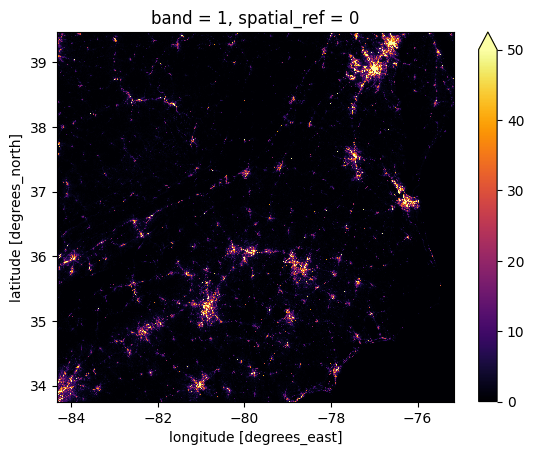

In [10]:
inferred_radiance_2021.plot(vmin=0, vmax=50, cmap='inferno')

In [8]:
import matplotlib.pyplot as plt
import geopandas as gpd
import config
import rioxarray
def plot_nc_urban_core(
    raster_da, 
    counties_shp_path, 
    title="Radiance Plot", 
    vmin=None, 
    vmax=None, 
    cmap='magma',
    buffer_deg=0.05,
    outline_color='white'
):
    """
    Clips and plots a raster focused on the Wake/Durham/Orange/Chatham urban core.
    Includes a fix to filter for NC counties only (avoiding Orange County, CA).
    """
    
    # 1. Setup Counties Vector
    counties = gpd.read_file(counties_shp_path)
    
    # FILTER FIX: We must specify State FIPS '37' (NC) to avoid grabbing 
    # Orange County, CA or Chatham County, GA.
    target_names = ['Wake', 'Durham', 'Orange', 'Chatham']
    
    roi_gdf = counties[
        (counties['NAME'].isin(target_names)) & 
        (counties['STATEFP'] == '37') # <--- CRITICAL FIX
    ]
    
    if roi_gdf.empty:
        raise ValueError("Could not find specified NC counties. Check STATEFP or names.")
        
    # Ensure CRS matches the raster
    if roi_gdf.crs != raster_da.rio.crs:
        roi_gdf = roi_gdf.to_crs(raster_da.rio.crs)

    # 2. Define Clip Extent
    minx, miny, maxx, maxy = roi_gdf.total_bounds
    
    # Add buffer
    minx -= buffer_deg
    miny -= buffer_deg
    maxx += buffer_deg
    maxy += buffer_deg
    
    # 3. Clip the Raster (Now calculates bounds only for NC counties)
    try:
        clipped_da = raster_da.rio.clip_box(minx, miny, maxx, maxy)
    except Exception:
        # Fallback if raster doesn't fully cover the area (e.g. edge cases)
        print("Warning: Clip extent might be outside raster bounds.")
        clipped_da = raster_da

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    
    # Plot Raster
    clipped_da.plot(
        ax=ax, 
        cmap=cmap, 
        vmin=vmin, 
        vmax=vmax, 
        add_colorbar=True,
        cbar_kwargs={'label': 'Radiance (nW/cm²/sr)', 'shrink': 0.8}
    )
    
    # Plot County Outlines
    roi_gdf.boundary.plot(
        ax=ax, 
        edgecolor=outline_color, 
        linewidth=1.5, 
        alpha=0.8
    )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_axis_off() 
    
    plt.tight_layout()
    plt.show()

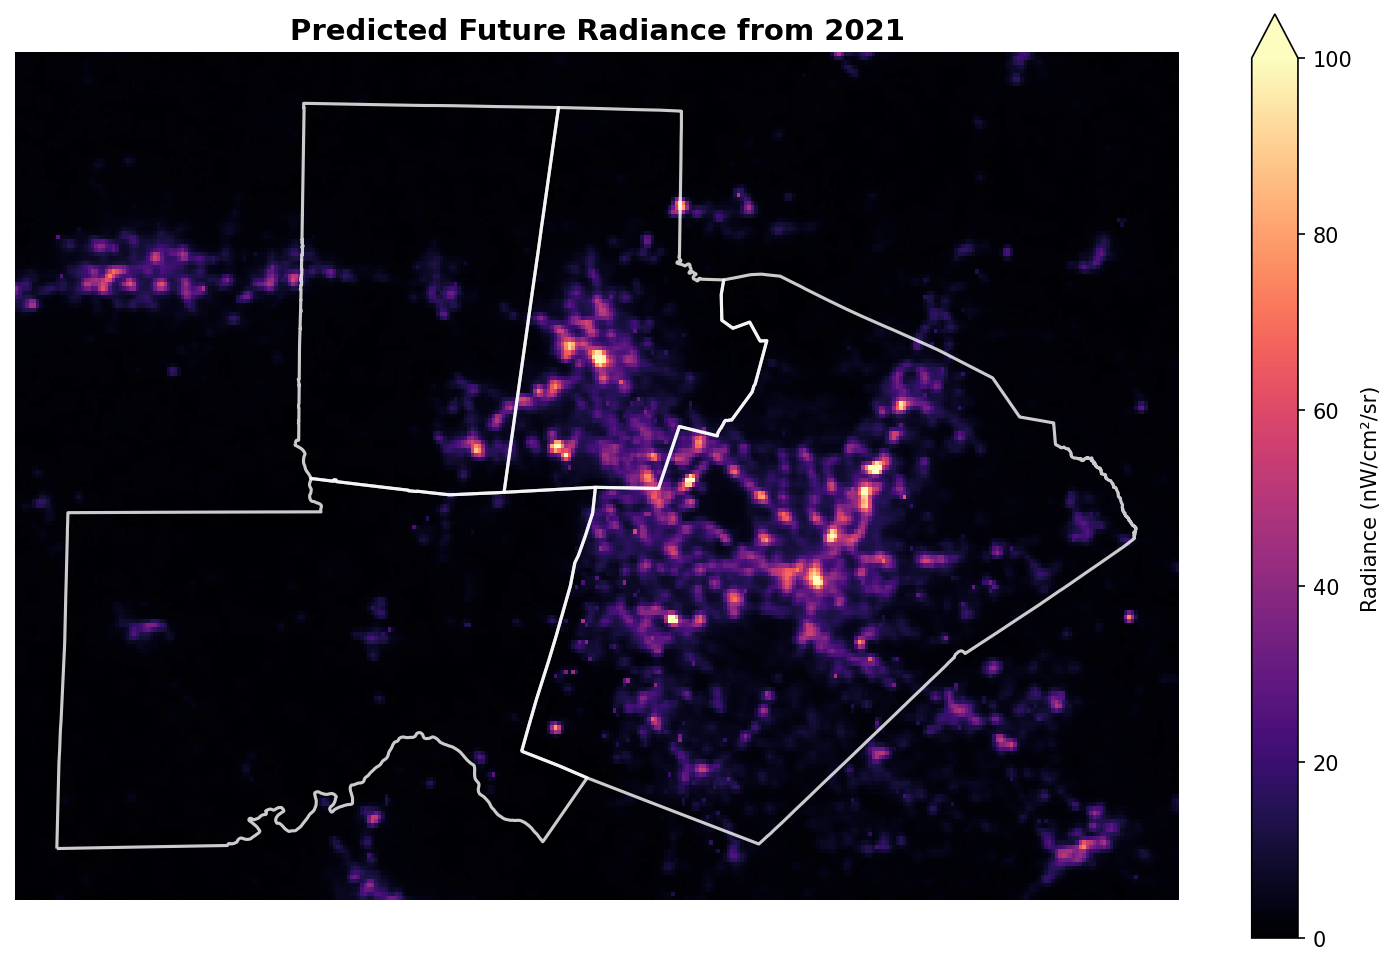

In [10]:
counties_path = config.COUNTIES_SHP # e.g. "data/tl_2024_us_county.shp"

# 1. Plot Future Radiance (0 to 100)
plot_nc_urban_core(
    inferred_radiance_2021, 
    counties_path, 
    title="Predicted Future Radiance from 2021", 
    vmin=0, 
    vmax=100, 
    cmap='magma'
)

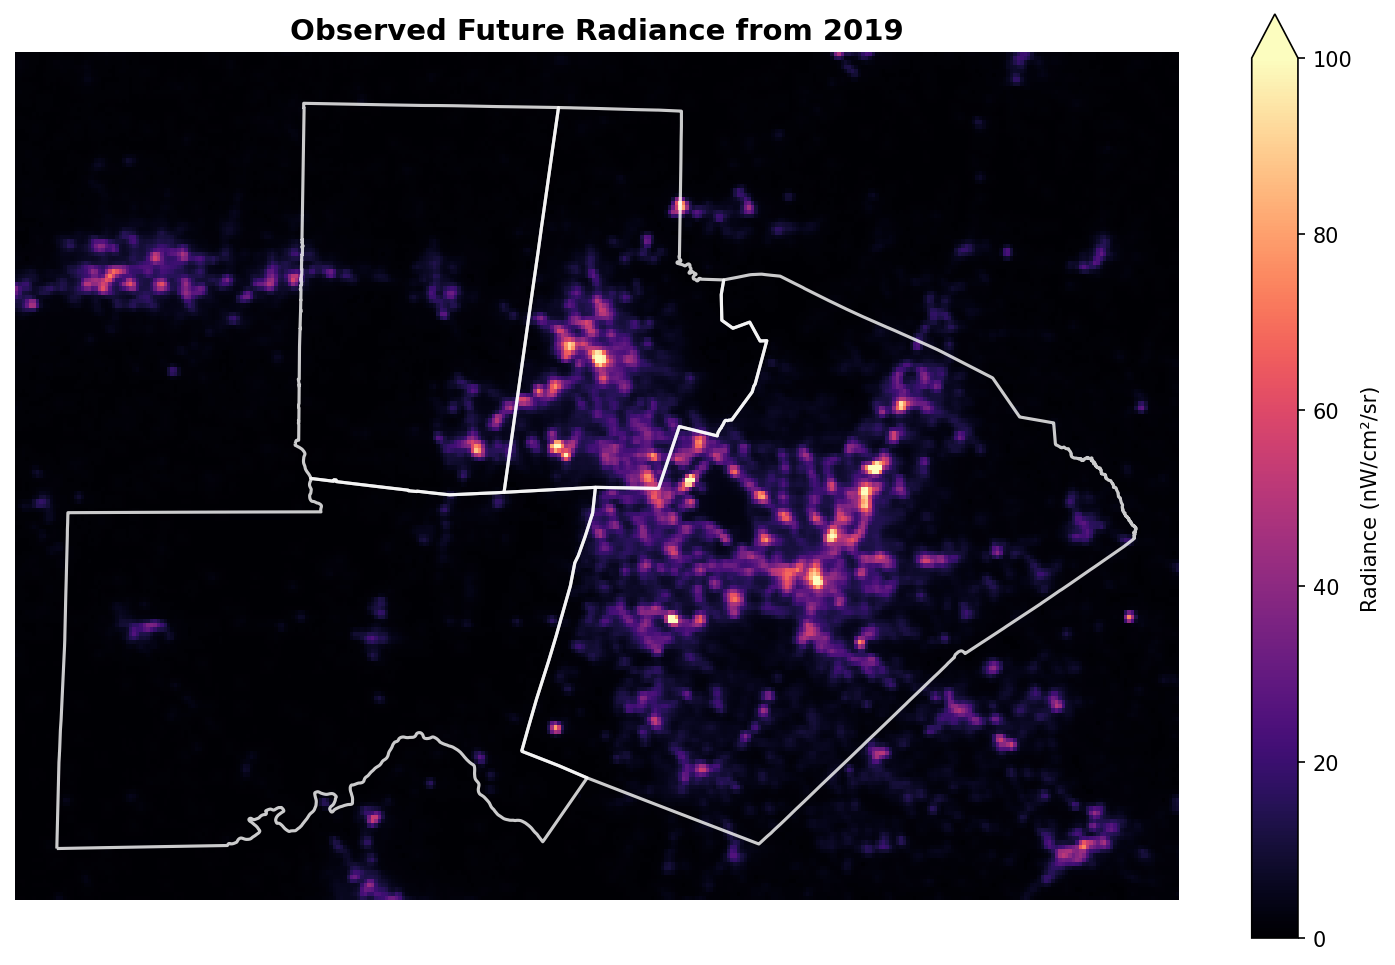

In [11]:
viirs_older_path = config.RADIANCE_OLDER
viirs_2019 = rioxarray.open_rasterio(viirs_older_path).squeeze()

plot_nc_urban_core(
    viirs_2019, 
    counties_path, 
    title="Observed Future Radiance from 2019", 
    vmin=0, 
    vmax=100, 
    cmap='magma'
)

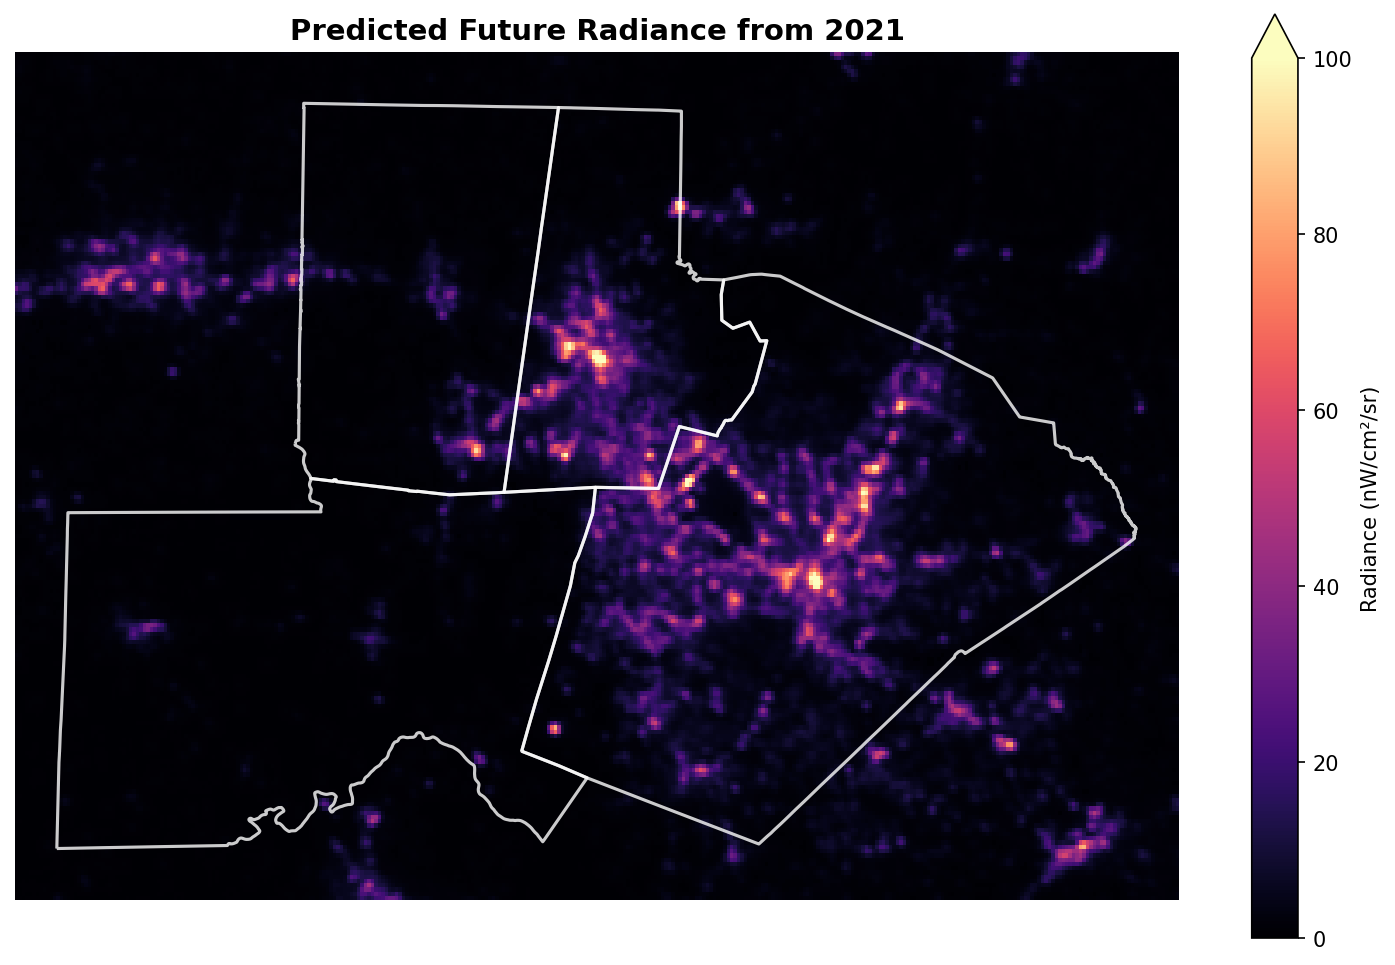

In [13]:
viirs_2021 = rioxarray.open_rasterio(config.RADIANCE_NEWER).squeeze()

plot_nc_urban_core(
    viirs_2021, 
    counties_path, 
    title="Predicted Future Radiance from 2021", 
    vmin=0, 
    vmax=100, 
    cmap='magma'
)

In [ ]:
viirs_2021_matched = viirs_2021.rio.reproject_match(viirs_2019)
observed_change = viirs_2021_matched - viirs_2019
plot_nc_urban_core(
    observed_change, 
    counties_path, 
    title="Observed Radiance Change (2021 - 2019)", 
    vmin=-100, 
    vmax=100, 
    cmap='bwr',
    outline_color='black'
)

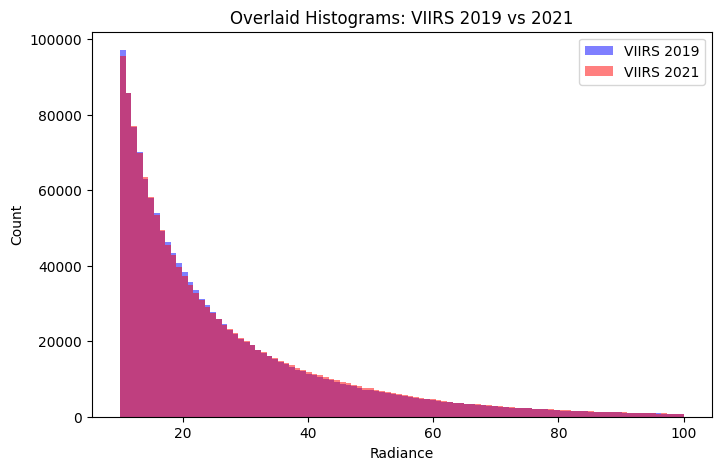

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Flatten and drop NaNs for both arrays
viirs_2019_flat = viirs_2019.values.flatten()
viirs_2021_flat = viirs_2021.values.flatten()
viirs_2019_flat = viirs_2019_flat[~np.isnan(viirs_2019_flat)]
viirs_2021_flat = viirs_2021_flat[~np.isnan(viirs_2021_flat)]

plt.figure(figsize=(8, 5))
plt.hist(viirs_2019_flat, bins=100, range=(10, 100), color='blue', alpha=0.5, label='VIIRS 2019')
plt.hist(viirs_2021_flat, bins=100, range=(10, 100), color='red', alpha=0.5, label='VIIRS 2021')
plt.xlabel('Radiance')
plt.ylabel('Count')
plt.legend()
plt.title('Overlaid Histograms: VIIRS 2019 vs 2021')
plt.show()

In [1]:
viirs_2019

NameError: name 'viirs_2019' is not defined

In [ ]:
import geopandas as gpd

# 1. Setup Counties Vector & Filter
# ---------------------------------------------------------
full_counties = gpd.read_file(config.COUNTIES_SHP)

# Filter for NC (37) and your specific counties
target_names = ['Wake', 'Durham', 'Orange', 'Chatham']
roi_gdf = full_counties[
    (full_counties['NAME'].isin(target_names)) & 
    (full_counties['STATEFP'] == '37')
]

if roi_gdf.empty:
    raise ValueError("Could not find specified NC counties.")

# Ensure CRS matches the raster (Crucial for alignment)
if roi_gdf.crs != observed_change.rio.crs:
    roi_gdf = roi_gdf.to_crs(observed_change.rio.crs)

# 2. Clip the Raster to the Counties
# ---------------------------------------------------------
# .rio.clip() cuts the raster to the exact polygon boundaries
# invert=False means "keep what is inside the shapes"
urban_core_change = observed_change.rio.clip(
    roi_gdf.geometry,
    roi_gdf.crs,
    drop=True,
    invert=False
)

# 3. Filter Outliers (Remove "No Data" Math Errors)
# ---------------------------------------------------------
# Real urban growth is rarely > 200. Anything higher is likely a sensor glitch.
valid_urban_change = urban_core_change.where(urban_core_change < 500)

# 4. Find Hotspots in the Urban Core
# ---------------------------------------------------------
threshold = -20 # Lower threshold since we are zoomed in
significant_growth = valid_urban_change.where(valid_urban_change < threshold, drop=True)

df_growth = significant_growth.to_dataframe(name='change').dropna().reset_index()
top_hotspots = df_growth.sort_values(by='change', ascending=True).head(10)

# 5. Reproject to Lat/Lon for readability
# ---------------------------------------------------------
gdf_hotspots = gpd.GeoDataFrame(
    top_hotspots,
    geometry=gpd.points_from_xy(top_hotspots.x, top_hotspots.y),
    crs=observed_change.rio.crs 
)
gdf_hotspots_ll = gdf_hotspots.to_crs(epsg=4326)

gdf_hotspots_ll['latitude'] = gdf_hotspots_ll.geometry.y
gdf_hotspots_ll['longitude'] = gdf_hotspots_ll.geometry.x

print("Top 10 Areas of reduction (Wake/Durham/Orange/Chatham Only):")
print(gdf_hotspots_ll[['latitude', 'longitude', 'change']])

Top 10 Areas of Growth (Wake/Durham/Orange/Chatham Only):
     latitude  longitude      change
39  35.887500 -78.566666 -126.070000
78  35.737500 -78.812499 -125.149994
73  35.741666 -78.812499 -123.849991
40  35.887500 -78.562499  -86.039993
77  35.737500 -78.816666  -79.029999
16  35.912500 -78.954166  -76.709999
20  35.908333 -78.954166  -66.980003
74  35.741666 -78.808333  -65.889999
17  35.912500 -78.949999  -63.969997
38  35.887500 -78.570833  -55.040001


In [28]:
import geopandas as gpd

# 1. Setup Counties Vector & Filter
# ---------------------------------------------------------
full_counties = gpd.read_file(config.COUNTIES_SHP)

# Filter for NC (37) and your specific counties
target_names = ['Wake', 'Durham', 'Orange', 'Chatham']
roi_gdf = full_counties[
    (full_counties['NAME'].isin(target_names)) & 
    (full_counties['STATEFP'] == '37')
]

if roi_gdf.empty:
    raise ValueError("Could not find specified NC counties.")

# Ensure CRS matches the raster (Crucial for alignment)
if roi_gdf.crs != observed_change.rio.crs:
    roi_gdf = roi_gdf.to_crs(observed_change.rio.crs)

# 2. Clip the Raster to the Counties
# ---------------------------------------------------------
# .rio.clip() cuts the raster to the exact polygon boundaries
# invert=False means "keep what is inside the shapes"
urban_core_change = observed_change.rio.clip(
    roi_gdf.geometry,
    roi_gdf.crs,
    drop=True,
    invert=False
)

# 3. Filter Outliers (Remove "No Data" Math Errors)
# ---------------------------------------------------------
# Real urban growth is rarely > 200. Anything higher is likely a sensor glitch.
valid_urban_change = urban_core_change.where(urban_core_change < 500)

# 4. Find Hotspots in the Urban Core
# ---------------------------------------------------------
threshold = 20 # Lower threshold since we are zoomed in
significant_growth = valid_urban_change.where(valid_urban_change > threshold, drop=True)

df_growth = significant_growth.to_dataframe(name='change').dropna().reset_index()
top_hotspots = df_growth.sort_values(by='change', ascending=False).head(10)

# 5. Reproject to Lat/Lon for readability
# ---------------------------------------------------------
gdf_hotspots = gpd.GeoDataFrame(
    top_hotspots,
    geometry=gpd.points_from_xy(top_hotspots.x, top_hotspots.y),
    crs=observed_change.rio.crs 
)
gdf_hotspots_ll = gdf_hotspots.to_crs(epsg=4326)

gdf_hotspots_ll['latitude'] = gdf_hotspots_ll.geometry.y
gdf_hotspots_ll['longitude'] = gdf_hotspots_ll.geometry.x

print("Top 10 Areas of Growth (Wake/Durham/Orange/Chatham Only):")
print(gdf_hotspots_ll[['latitude', 'longitude', 'change']])

Top 10 Areas of Growth (Wake/Durham/Orange/Chatham Only):
     latitude  longitude     change
91  35.629166 -78.954166  85.379997
29  35.900000 -78.945833  62.550003
85  35.716666 -78.587499  61.270000
37  35.895833 -78.808333  52.770004
36  35.895833 -78.812499  50.100002
88  35.712500 -78.587499  49.870003
50  35.837500 -78.645833  48.970001
39  35.891666 -78.808333  45.389999
19  35.962500 -78.979166  44.989998
0   36.145833 -78.812499  40.219997
